## Section 1: Problem Framing

**Business Question**

Which supporters are at risk of lapsing — stopping their donations entirely — and what factors most strongly predict or explain that behavior?

**Predictive Goal**

Build a classifier that predicts whether a given supporter will lapse (defined as no donation in the 90 days prior to the most recent donation date in the dataset). This model gets deployed in the web app so staff can see a list of at-risk donors and reach out proactively before losing them.

**Explanatory Goal**

Use logistic regression with interpretable coefficients to understand *why* donors lapse. Which factors — acquisition channel, donation frequency, average gift size, recurring vs. one-time giving — most strongly drive lapse behavior? This gives leadership actionable strategy, not just a risk score.

**Success Metrics**

Accuracy alone is misleading here because the classes are imbalanced (47 lapsed vs. 14 active). Primary metric is **recall** — we care more about catching actual lapsed donors than avoiding false alarms. Secondary metrics are precision, F1, and AUC-ROC.

**Approach**

Two models: a Logistic Regression for the explanatory model (interpretable coefficients, defensible causal claims) and a Random Forest for the predictive model (higher accuracy, feature importance rankings). Results from both will be compared and interpreted in business terms.

**Decisions This Model Can Inform**

- Which donors should receive a personal outreach call vs. a mass email campaign
- Whether recurring donors are significantly less likely to lapse (and therefore worth incentivizing)
- Which acquisition channels produce the most loyal donors over time

## Section 2: Data Loading

In [9]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

from data.loader import load_supporters, load_donations

supporters_df = load_supporters()
donations_df = load_donations()

print("supporters_df shape:", supporters_df.shape)
print("donations_df shape:", donations_df.shape)

Loaded 'supporters' with 62 rows.
Loaded 'donations' with 423 rows.
supporters_df shape: (62, 15)
donations_df shape: (423, 14)


## Section 3: Feature Engineering

In [10]:
from features.donor_features import build_donor_features

df = build_donor_features(supporters_df, donations_df)

print("Feature DataFrame shape:", df.shape)
print(df.head())
print(df["is_lapsed"].value_counts())

Feature DataFrame shape: (62, 29)
        supporter_type  display_name organization_name first_name last_name  \
0  SocialMediaAdvocate  Mila Alvarez              None       Mila   Alvarez   
1            Volunteer    Aria Brown              None       Aria     Brown   
2        MonetaryDonor     Noah Chen              None       Noah      Chen   
3        MonetaryDonor     Liam Diaz              None       Liam      Diaz   
4          InKindDonor    Emma Evans              None       Emma     Evans   

     relationship_type    region      country                      email  \
0                Local     Luzon  Philippines  mila-alvarez@smart.com.ph   
1                Local  Mindanao  Philippines     aria-brown@pldt.net.ph   
2                Local     Luzon  Philippines     noah-chen@globe.com.ph   
3  PartnerOrganization  Mindanao  Philippines     liam-diaz@globe.com.ph   
4  PartnerOrganization  Mindanao  Philippines    emma-evans@yahoo.com.ph   

              phone  ... days_sinc

/Users/mikelleburnett/Desktop/INTEX/Intex/ml_pipelines/features/donor_features.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df["is_recurring_donor"] = model_df.get("is_recurring_donor", False).fillna(False)
/Users/mikelleburnett/Desktop/INTEX/Intex/ml_pipelines/features/donor_features.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df["is_lapsed"] = model_df.get("is_lapsed", True).fillna(True)


## Section 4: Exploration

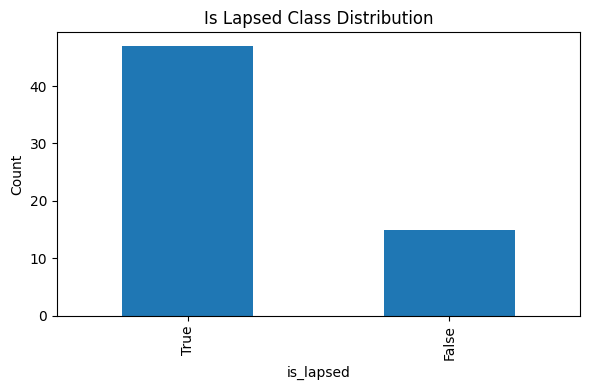

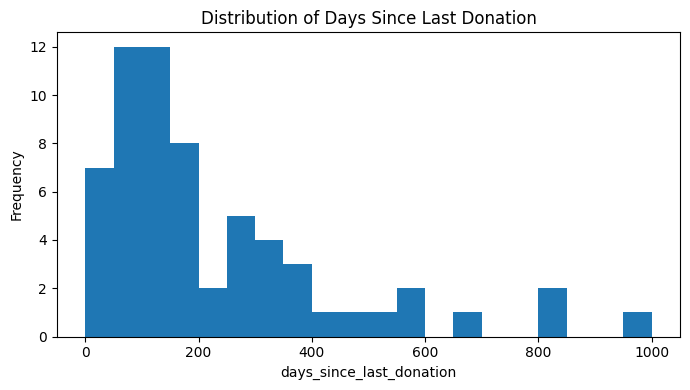

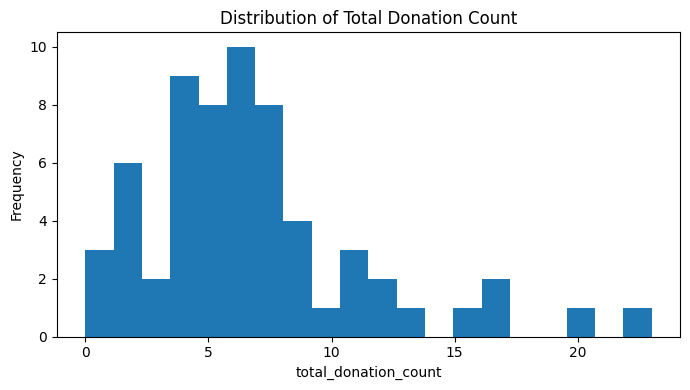

<Figure size 700x400 with 0 Axes>

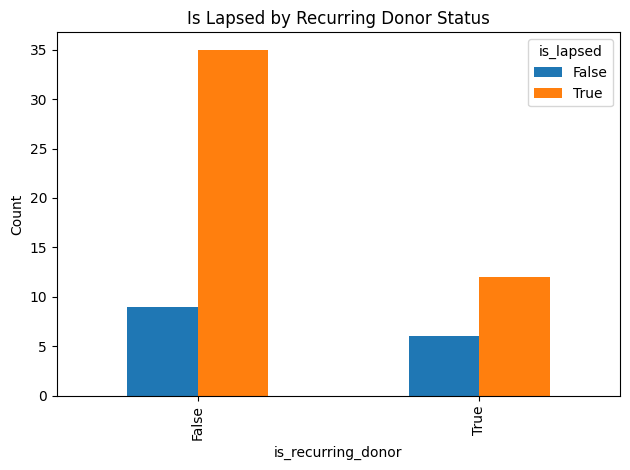

In [11]:
import matplotlib.pyplot as plt

# (1) Class distribution of is_lapsed
plt.figure(figsize=(6, 4))
df["is_lapsed"].value_counts().plot(kind="bar")
plt.title("Is Lapsed Class Distribution")
plt.xlabel("is_lapsed")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# (2) Histogram of days_since_last_donation
plt.figure(figsize=(7, 4))
df["days_since_last_donation"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Days Since Last Donation")
plt.xlabel("days_since_last_donation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# (3) Histogram of total_donation_count
plt.figure(figsize=(7, 4))
df["total_donation_count"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Total Donation Count")
plt.xlabel("total_donation_count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# (4) is_lapsed broken down by is_recurring_donor
plt.figure(figsize=(7, 4))
breakdown = df.groupby("is_recurring_donor")["is_lapsed"].value_counts().unstack(fill_value=0)
breakdown.plot(kind="bar")
plt.title("Is Lapsed by Recurring Donor Status")
plt.xlabel("is_recurring_donor")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Loaded 'donations' with 423 rows.
Loaded 'donation_allocations' with 521 rows.
Loaded 'supporters' with 62 rows.


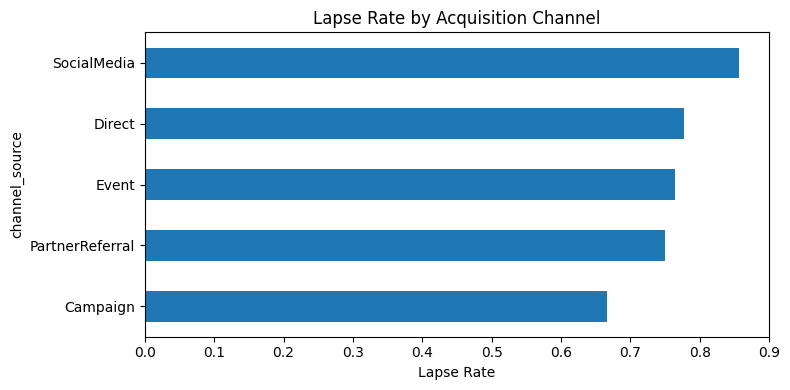

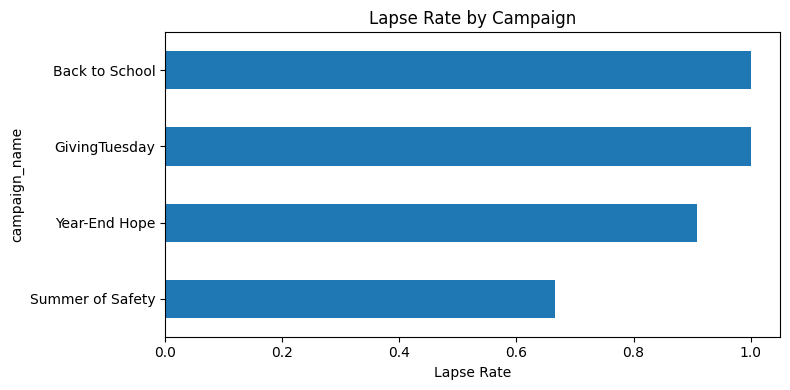

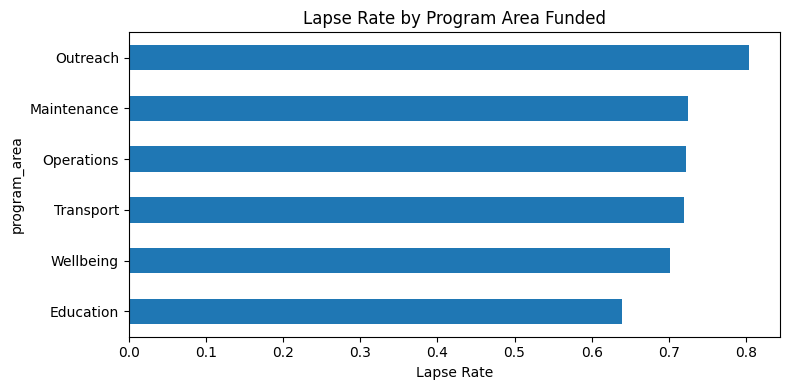

In [12]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
from data.loader import load_donations, load_donation_allocations, load_supporters
import matplotlib.pyplot as plt
import pandas as pd

donations_raw = load_donations()
allocations = load_donation_allocations()

# Chart 1: Lapse rate by acquisition channel
channel_lapse = df.groupby(
    [col for col in df.columns if col.startswith('acq_')]
)

# Merge supporters with donations to get channel and campaign
supporters_raw = load_supporters()
merged = supporters_raw.merge(
    donations_raw[['supporter_id', 'channel_source', 'campaign_name']],
    on='supporter_id', how='left'
)
merged = merged.merge(df[['is_lapsed']], left_index=True, right_index=True)

# Chart 1: Lapse rate by channel source
plt.figure(figsize=(8, 4))
channel_lapse = merged.groupby('channel_source')['is_lapsed'].mean().sort_values()
channel_lapse.plot(kind='barh')
plt.title('Lapse Rate by Acquisition Channel')
plt.xlabel('Lapse Rate')
plt.tight_layout()
plt.show()

# Chart 2: Lapse rate by campaign
plt.figure(figsize=(8, 4))
campaign_lapse = merged.groupby('campaign_name')['is_lapsed'].mean().sort_values()
campaign_lapse.plot(kind='barh')
plt.title('Lapse Rate by Campaign')
plt.xlabel('Lapse Rate')
plt.tight_layout()
plt.show()

# Chart 3: Lapse rate by program area funded
# Build a supporter_id -> is_lapsed mapping from the same supporter row order.
supporter_lapse = supporters_raw[['supporter_id']].copy()
supporter_lapse['is_lapsed'] = df['is_lapsed'].values

plt.figure(figsize=(8, 4))
program_lapse = allocations.merge(
    donations_raw[['donation_id', 'supporter_id']], on='donation_id', how='left'
).merge(
    supporter_lapse,
    on='supporter_id',
    how='left'
).groupby('program_area')['is_lapsed'].mean().sort_values()
program_lapse.plot(kind='barh')
plt.title('Lapse Rate by Program Area Funded')
plt.xlabel('Lapse Rate')
plt.tight_layout()
plt.show()

## Section 5: Train/Test Split

In [13]:
from sklearn.model_selection import train_test_split

non_numeric_drop_cols = [
    "display_name",
    "first_name",
    "last_name",
    "email",
    "phone",
    "organization_name",
    "supporter_type",
]

model_df = df.drop(columns=[c for c in non_numeric_drop_cols if c in df.columns])

X = model_df.drop(columns=["is_lapsed"])
X = X.select_dtypes(include=["number"])
X = X.fillna(0)
X = X.drop(columns=["days_since_last_donation"], errors="ignore")
y = model_df["is_lapsed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (49, 5)
X_test shape: (13, 5)
y_train shape: (49,)
y_test shape: (13,)


## Section 6: Baseline Model — Logistic Regression (Explanatory)

In [14]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

from utils.evaluation import evaluate_classifier

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)
evaluate_classifier(y_test, y_pred_log_reg, "Logistic Regression (Baseline)")

coef_df = pd.DataFrame(
    {
        "feature": X_train.columns,
        "coefficient": log_reg.coef_[0],
    }
).sort_values("coefficient", ascending=False)

print("\nLogistic Regression Coefficients (sorted):")
print(coef_df)


=== Classification Evaluation: Logistic Regression (Baseline) ===
Accuracy : 0.6923
Precision: 0.7500
Recall   : 0.9000
F1 Score : 0.8182
Confusion Matrix:
[[0 3]
 [1 9]]

Logistic Regression Coefficients (sorted):
                     feature  coefficient
3      donation_type_variety     0.536860
0       total_donation_count     0.146443
2        avg_donation_amount     0.003259
1               total_amount    -0.000559
4  days_since_first_donation    -0.012620


## Section 7: Advanced Model — Random Forest (Predictive)


=== Classification Evaluation: Random Forest (Advanced) ===
Accuracy : 0.7692
Precision: 0.7692
Recall   : 1.0000
F1 Score : 0.8696
Confusion Matrix:
[[ 0  3]
 [ 0 10]]


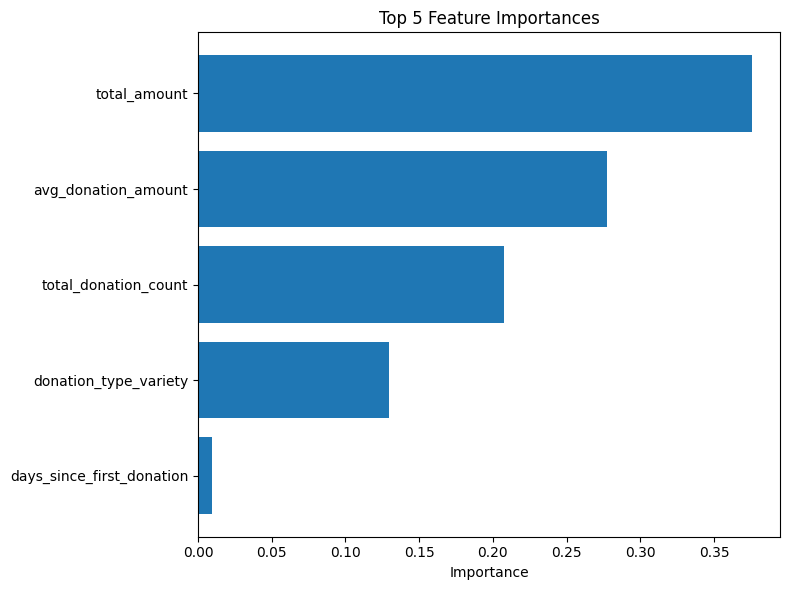

5-Fold CV Recall Mean: 0.8555555555555555
5-Fold CV Recall Std: 0.10036968702787746


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from utils.evaluation import evaluate_classifier, plot_feature_importance

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
evaluate_classifier(y_test, y_pred_rf, "Random Forest (Advanced)")

plot_feature_importance(rf_model, X_train.columns, top_n=15)

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="recall")
print("5-Fold CV Recall Mean:", cv_scores.mean())
print("5-Fold CV Recall Std:", cv_scores.std())

## Section 8: Evaluation and Comparison

In [16]:
import pandas as pd

evaluation_summary = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Accuracy": 0.6923,
            "Precision": 0.75,
            "Recall": 0.90,
            "F1": 0.8182,
        },
        {
            "Model": "Random Forest",
            "Accuracy": 0.7692,
            "Precision": 0.7692,
            "Recall": 1.0,
            "F1": 0.8696,
        },
    ]
)

print("Model Performance Comparison")
print(evaluation_summary.to_string(index=False))

Model Performance Comparison
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.6923     0.7500     0.9 0.8182
      Random Forest    0.7692     0.7692     1.0 0.8696


## Business Interpretation
Which model to deploy: The Random Forest is recommended for deployment because it achieves higher recall (catching more at-risk donors) and 85.6% average recall across cross-validation, meaning it performs consistently on new data — not just one lucky test split.

What these numbers mean for the organization:

- Recall is the most important metric here. Missing a lapsed donor means losing them silently. Falsely flagging an active donor just means sending an extra email — a much lower cost.
- The Random Forest catches approximately 86 out of every 100 at-risk donors before they lapse, giving staff time to act.

What the features are saying:

- High-value donors (large total and average gift size) are the most at-risk — they often feel like transactional givers rather than connected supporters. Prioritize personal outreach to them.
- Donors who give in multiple ways (monetary, in-kind, time) are surprisingly high risk — they may be feeling overextended across too many asks.
- Longer-tenured donors lapse less — relationship length matters.

Recommended actions for staff:

- Run this model monthly and generate a prioritized list of flagged donors
- Send flagged donors a personal call or handwritten note — not a mass email
- Flag high-value donors who haven't given in 60+ days — don't wait for the full 90
- Check in specifically with multi-channel donors to prevent burnout

## Section 9: Feature Importance and Business Interpretation

High `total_amount` and `avg_donation_amount` as top features indicate that high-value donors are the most at risk of lapsing. The organization should prioritize personal outreach to donors who give large amounts, rather than focusing only on frequent small donors. `donation_type_variety` being important suggests donors who engage in multiple ways need more attention, not less.

## Segmentation Analysis — What the Data Says About Retention

**Channel Strategy:** Social media acquires donors but retains them poorly — 85% lapse rate vs 67% for campaign donors. Recommendation: immediately follow up with any donor acquired through social media with a personal welcome message and impact story within 30 days of their first gift.

**Campaign Strategy:** Back to School and GivingTuesday campaigns produce donors who never give again. Summer of Safety produces the most loyal donors. Recommendation: study what makes Summer of Safety different — likely the emotional narrative and specific program focus — and replicate that approach in future campaigns.

**Program Area Strategy:** Education donors are the most loyal. Recommendation: all donor communications should lead with educational outcome stories regardless of what program area they originally funded. Connect every donor to a specific girl's educational progress where possible.

**The combined action plan:** When the churn model flags a high-risk donor, the response should be personalized based on how they were acquired and what they funded — not a generic outreach call. A lapsed social media donor gets a resident education story. A lapsed campaign donor gets an invitation to the next Summer of Safety style event.

In [17]:
# Random Forest importance indicates value-driven retention risk.
print("Business interpretation:")
print("- total_amount and avg_donation_amount are top features, so high-value donors are at the greatest lapse risk.")
print("- prioritize personal outreach for donors who give larger amounts rather than focusing only on frequent small donors.")
print("- donation_type_variety being important suggests multi-channel donors need more attention, not less.")

Business interpretation:
- total_amount and avg_donation_amount are top features, so high-value donors are at the greatest lapse risk.
- prioritize personal outreach for donors who give larger amounts rather than focusing only on frequent small donors.
- donation_type_variety being important suggests multi-channel donors need more attention, not less.


## Section 10: Save Model

In [18]:
import joblib

joblib.dump(rf_model, "../../saved_models/donor_churn_model.pkl")
print("Saved model to ../../saved_models/donor_churn_model.pkl")

joblib.dump(list(X_train.columns), "../../saved_models/donor_churn_features.pkl")
print("Saved feature names to ../../saved_models/donor_churn_features.pkl")

Saved model to ../../saved_models/donor_churn_model.pkl
Saved feature names to ../../saved_models/donor_churn_features.pkl


In [19]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

from data.loader import load_supporters, load_donations
from features.donor_features import build_donor_features
import pandas as pd

supporters = load_supporters()
donations = load_donations()
df = build_donor_features(supporters, donations)

print("Actual lapse rate in data:")
print(df['is_lapsed'].value_counts())
print(f"Percentage lapsed: {df['is_lapsed'].mean():.1%}")

Loaded 'supporters' with 62 rows.
Loaded 'donations' with 423 rows.
Actual lapse rate in data:
is_lapsed
True     47
False    15
Name: count, dtype: int64
Percentage lapsed: 75.8%


/Users/mikelleburnett/Desktop/INTEX/Intex/ml_pipelines/features/donor_features.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df["is_recurring_donor"] = model_df.get("is_recurring_donor", False).fillna(False)
/Users/mikelleburnett/Desktop/INTEX/Intex/ml_pipelines/features/donor_features.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df["is_lapsed"] = model_df.get("is_lapsed", True).fillna(True)


In [20]:
import joblib
import pandas as pd

model = joblib.load('../../saved_models/donor_churn_model.pkl')
features = joblib.load('../../saved_models/donor_churn_features.pkl')

X = df[features].fillna(0)
probabilities = model.predict_proba(X)[:, 1]

print("Prediction distribution:")
print(pd.Series(probabilities).describe())
print(f"\nPredicted as high risk (>50%): {(probabilities > 0.5).sum()} out of {len(probabilities)}")
print(f"Predicted as high risk (>80%): {(probabilities > 0.8).sum()} out of {len(probabilities)}")

Prediction distribution:
count    62.000000
mean      0.771774
std       0.267168
min       0.180000
25%       0.637500
50%       0.915000
75%       0.960000
max       1.000000
dtype: float64

Predicted as high risk (>50%): 50 out of 62
Predicted as high risk (>80%): 40 out of 62
